In [1]:
import sys, time
print("python:", sys.executable, flush=True)
print("time:", time.time(), flush=True)

python: c:\Users\guill\GitHub\IFT6135-Assignments\assignment-3\.venv\Scripts\python.exe
time: 1777144479.8301654


# Question 3: RLHF, Reward Modeling, DPO, and Best-of-N

This notebook guides you through the alignment part of Assignment 3. You will train a reward model, optimize a policy with DPO, and evaluate Best-of-N sampling using:
- a packaged GPT-2 SFT checkpoint in `artifacts/q3_rlhf/sft_gpt2/`
- a packaged instruction-following preference dataset in `artifacts/q3_rlhf/instruction-prefernce.json`

Primary references:
- RLHF pipeline: [Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155) by Ouyang et al. (2022)
- DPO: [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290) by Rafailov et al. (2023)

Throughout Q3, this SFT checkpoint is the common starting point for all three parts:
- Part 1 uses the SFT model as the backbone of a reward model, which learns to score complete prompt-response pairs.
- Part 2 initializes two copies from the same SFT checkpoint: a frozen **reference model** and a trainable **policy model**. DPO updates only the policy model.
- Part 3 keeps the trained policy fixed and uses the reward model at inference time to rank multiple sampled responses in Best-of-N.

To summarize: first we learn a scorer from preferences, next we use preferences to improve the generator itself, and finally we reuse the scorer to select among generated candidates.

The packaged checkpoint in this release lives in `artifacts/q3_rlhf/sft_gpt2/`. It is an SFT GPT-2-style causal language model prepared for this assignment; for the base GPT-2 architecture, see the [GPT-2 model card](https://huggingface.co/openai-community/gpt2).

Complete these files before running the training sections:
- `q3_reward_model.py`
- `q3_dpo.py`
- `q3_bon.py`

Provided support files:
- `q3_utils.py`
- `q3_training.py`
- `requirements.txt`

The assignment questions stay the same. Only the provided SFT model and preference dataset have changed.


<img src="https://github.com/JingYue2000/HW_Supporting_materials/blob/main/RLHFvsDPO.png?raw=true" width=500px>

*Figure: RLHF trains a separate reward model and uses reinforcement learning to optimize the policy, while DPO directly optimizes from preference data.*


## Colab setup

Recommended workflow for Colab:
1. Download `assignment3_release.zip`, unzip it on your computer first, and upload the extracted `assignment3_release/` folder to Google Drive. Do not upload the zip file to Drive.
2. Open the notebook from Google Drive in Colab and mount Drive.
3. Run the setup cells below to locate the extracted release folder.
4. Upload the provided `artifacts/` folder into the extracted release root in Drive.
5. Complete the TODOs in `q3_reward_model.py`, `q3_dpo.py`, and `q3_bon.py`.
6. Re-run the notebook from the top before training.


In [2]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    IN_COLAB = False


## Dependency install

This notebook only adds the Hugging Face packages that are not already present in a standard Colab runtime.


In [3]:
import importlib
import subprocess
import sys

REQUIRED_PACKAGES = ['transformers', 'datasets', 'accelerate', 'safetensors']
for package in REQUIRED_PACKAGES:
    try:
        importlib.import_module(package)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', package])


c:\Users\guill\GitHub\IFT6135-Assignments\assignment-3\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## Project-root discovery

The next cell finds the extracted Assignment 3 release folder, changes into it, and adds it to `sys.path`.


In [4]:
import os
import sys
from pathlib import Path


def _candidate_roots(cwd: Path):
    candidates = [
        Path('/content/drive/MyDrive/assignment3_release-new'),
        Path('/content/drive/MyDrive/assignment3_release'),
        Path('/content/assignment3_release-new'),
        Path('/content/assignment3_release'),
        cwd,
    ]
    for parent in [cwd, *cwd.parents]:
        candidates.append(parent / 'assignment3_release-new')
        candidates.append(parent / 'assignment3_release')
    return candidates


def _is_project_root(path: Path, marker: str) -> bool:
    return path.is_dir() and (path / marker).exists()


def find_project_root(marker: str) -> Path:
    cwd = Path.cwd().resolve()
    seen_roots = set()
    for candidate in _candidate_roots(cwd):
        candidate = candidate.expanduser().resolve()
        if candidate in seen_roots:
            continue
        seen_roots.add(candidate)
        if _is_project_root(candidate, marker):
            return candidate

    raise FileNotFoundError(
        'Could not locate the Assignment 3 release folder. '
        'Unzip the release package on your computer first, upload the extracted assignment3_release-new folder to Google Drive, '
        'open the notebook from that folder, and rerun this cell.'
    )


PROJECT_ROOT = find_project_root('q3_utils.py')
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\guill\GitHub\IFT6135-Assignments\assignment-3


## Dataset And Model Check

This release expects the packaged dataset and SFT checkpoint to already be present inside the extracted folder:
- `artifacts/q3_rlhf/instruction-prefernce.json`
- `artifacts/q3_rlhf/sft_gpt2/`


In [5]:
from q3_utils import get_q3_artifact_paths

ARTIFACT_PATHS = get_q3_artifact_paths(PROJECT_ROOT)
for name, path in ARTIFACT_PATHS.items():
    print(f'{name}: {path}')

required_keys = ['preference_dataset', 'sft_model_dir']
missing = [name for name in required_keys if not ARTIFACT_PATHS[name].exists()]
if missing:
    expected_layout = '\n'.join(
        [
            f"- {ARTIFACT_PATHS['preference_dataset']}",
            f"- {ARTIFACT_PATHS['sft_model_dir']}",
        ]
    )
    raise FileNotFoundError(
        'Q3 requires the packaged instruction-preference dataset and SFT checkpoint before the training sections can run.\n'
        'Make sure the extracted release folder contains these paths:\n'
        f'{expected_layout}'
    )

print('Packaged dataset and SFT checkpoint found. Full training and evaluation cells can run.')


artifact_root: C:\Users\guill\GitHub\IFT6135-Assignments\assignment-3\artifacts\q3_rlhf
preference_dataset: C:\Users\guill\GitHub\IFT6135-Assignments\assignment-3\artifacts\q3_rlhf\instruction-preference.json
sft_model_dir: C:\Users\guill\GitHub\IFT6135-Assignments\assignment-3\artifacts\q3_rlhf\sft_gpt2
Packaged dataset and SFT checkpoint found. Full training and evaluation cells can run.


## Preference-Data Preprocessing

The raw dataset stores one instruction-following preference pair per example with these fields:
- `instruction`
- `input`
- `chosen`
- `rejected`

`q3_utils.py` converts each raw record into the normalized structure used by the rest of the Q3 pipeline:
- `prompt`
- `chosen_response`
- `rejected_response`

The prompt uses the same Alpaca-style template that was used for the `ch07` SFT model.


In [6]:
PREFERENCE_TEST_RATIO = 0.1
PREFERENCE_MIN_TEST_SIZE = 50
PREFERENCE_SPLIT_SEED = 42


## Data loading and split


In [7]:
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

from q3_bon import best_of_n_sample
from q3_dpo import DPOTrainer, compute_dpo_loss, compute_implicit_reward
from q3_reward_model import RewardModel, RewardModelTrainer, compute_preference_loss, compute_reward_accuracy
from q3_training import build_preference_loader, evaluate_best_of_n_curve, slice_records, train_dpo, train_reward_model
from q3_utils import (
    DEFAULT_ANALYSIS_PROMPTS,
    DEFAULT_MAX_LENGTH,
    load_preference_records,
    mean_reward_by_n,
    set_seed,
)

set_seed(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

RM_BATCH_SIZE = 4
DPO_BATCH_SIZE = 4
RM_GRAD_ACCUM_STEPS = 4
DPO_GRAD_ACCUM_STEPS = 8
RM_EPOCHS = 3
DPO_EPOCHS = 3
RM_LR = 1e-5
DPO_LR = 5e-6
RM_TRAIN_LIMIT = None
DPO_TRAIN_LIMIT = None
EVAL_LIMIT = 256
TRAINING_LOG_EVERY = 25
RM_EVAL_EVERY = 100
DPO_EVAL_EVERY = 100
PLOT_SMOOTHING_WINDOW = 25
PLOT_Y_LIMIT_WARMUP_EPOCHS = 0.03
REPORT_PROMPT_COUNT = 5
REPORT_N_VALUES = [1, 4, 8, 16, 32]
REPORT_MAX_NEW_TOKENS = 48
REPORT_TEMPERATURE = 0.8

reward_model = None
policy_model_for_eval = None
tokenizer = None
rm_train_loader = None
rm_eval_loader = None
dpo_train_loader = None
dpo_eval_loader = None
rm_train_history = []
rm_eval_history = []
dpo_train_history = []
dpo_eval_history = []
report_prompts = DEFAULT_ANALYSIS_PROMPTS[:REPORT_PROMPT_COUNT]

all_records = load_preference_records(ARTIFACT_PATHS['preference_dataset'])
if len(all_records) < 2:
    raise ValueError('The packaged preference dataset must contain at least two examples.')

rng = random.Random(PREFERENCE_SPLIT_SEED)
shuffled_records = list(all_records)
rng.shuffle(shuffled_records)

test_size = max(PREFERENCE_MIN_TEST_SIZE, int(len(shuffled_records) * PREFERENCE_TEST_RATIO))
test_size = min(test_size, len(shuffled_records) - 1)
train_records = shuffled_records[test_size:]
test_records = shuffled_records[:test_size]

tokenizer = AutoTokenizer.from_pretrained(ARTIFACT_PATHS['sft_model_dir'])
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

rm_train_records = slice_records(train_records, RM_TRAIN_LIMIT)
dpo_train_records = slice_records(train_records, DPO_TRAIN_LIMIT)
eval_records = slice_records(test_records, EVAL_LIMIT)

rm_train_loader = build_preference_loader(rm_train_records, tokenizer, batch_size=RM_BATCH_SIZE, shuffle=True, max_length=DEFAULT_MAX_LENGTH)
rm_eval_loader = build_preference_loader(eval_records, tokenizer, batch_size=RM_BATCH_SIZE, shuffle=False, max_length=DEFAULT_MAX_LENGTH)
dpo_train_loader = build_preference_loader(dpo_train_records, tokenizer, batch_size=DPO_BATCH_SIZE, shuffle=True, max_length=DEFAULT_MAX_LENGTH)
dpo_eval_loader = build_preference_loader(eval_records, tokenizer, batch_size=DPO_BATCH_SIZE, shuffle=False, max_length=DEFAULT_MAX_LENGTH)
report_prompts = [record['prompt'] for record in test_records[:REPORT_PROMPT_COUNT]]

print(f'Loaded {len(all_records)} normalized preference examples from {ARTIFACT_PATHS["preference_dataset"]}.')
print(f'Created a train/test split with {len(train_records)} train examples and {len(test_records)} test examples.')
print(f'Reward-model training examples used in this notebook: {len(rm_train_records)}')
print(f'DPO training examples used in this notebook: {len(dpo_train_records)}')
print(f'Evaluation examples used in this notebook: {len(eval_records)}')
print(json.dumps(train_records[0], indent=2)[:1200])


def moving_average(values, window):
    if window <= 1 or len(values) < window:
        return list(values)
    kernel = np.ones(window, dtype=float) / float(window)
    smoothed = np.convolve(np.asarray(values, dtype=float), kernel, mode='valid')
    prefix = list(values[: window - 1])
    return prefix + smoothed.tolist()


def set_axis_limits(ax, values, include_zero=False, lower_bound=None, upper_bound=None):
    if not values:
        return
    lower = float(min(values))
    upper = float(max(values))
    if include_zero:
        lower = min(lower, 0.0)
        upper = max(upper, 0.0)
    if np.isclose(lower, upper):
        pad = 0.05 if np.isclose(lower, 0.0) else 0.05 * abs(lower)
    else:
        pad = 0.1 * (upper - lower)
    lower -= pad
    upper += pad
    if lower_bound is not None:
        lower = max(lower, lower_bound)
    if upper_bound is not None:
        upper = min(upper, upper_bound)
    ax.set_ylim(lower, upper)


def plot_train_eval_curve(
    ax,
    train_history,
    eval_history,
    metric_key,
    train_label,
    eval_label,
    ylabel,
    title,
    steps_per_epoch,
    smoothing_window=1,
    y_limit_min_epoch=0.0,
    include_zero=False,
):
    train_epochs = [
        (entry['global_step'] - 1) / max(1, steps_per_epoch) + 1.0
        for entry in train_history
        if metric_key in entry
    ]
    train_values = [entry[metric_key] for entry in train_history if metric_key in entry]
    smoothed_train_values = moving_average(train_values, smoothing_window)
    ax.plot(train_epochs, smoothed_train_values, label=train_label)

    eval_epochs = [
        (entry['global_step'] - 1) / max(1, steps_per_epoch) + 1.0
        for entry in eval_history
        if metric_key in entry
    ]
    eval_values = [entry[metric_key] for entry in eval_history if metric_key in entry]
    if eval_epochs:
        ax.plot(eval_epochs, eval_values, marker='o', linestyle='--', label=eval_label)

    visible_values = [
        value
        for epoch, value in zip(train_epochs, smoothed_train_values)
        if epoch >= y_limit_min_epoch
    ]
    visible_values.extend(
        value
        for epoch, value in zip(eval_epochs, eval_values)
        if epoch >= y_limit_min_epoch
    )
    set_axis_limits(ax, visible_values, include_zero=include_zero)

    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend()


Using device: cuda
Loaded 1100 normalized preference examples from C:\Users\guill\GitHub\IFT6135-Assignments\assignment-3\artifacts\q3_rlhf\instruction-preference.json.
Created a train/test split with 990 train examples and 110 test examples.
Reward-model training examples used in this notebook: 990
DPO training examples used in this notebook: 990
Evaluation examples used in this notebook: 110
{
  "prompt": "Below is an instruction that describes a task. Write a response that appropriately completes the request.\n\n### Instruction:\nWhat is the opposite of 'soft'?\n\n### Response:\n",
  "chosen_response": "The opposite of 'soft' is 'hard'.",
  "rejected_response": "Obviously, the opposite of 'soft' is 'hard', get it straight."
}



## Quick data preview

This section previews a few prepared preference examples so you can verify the prompt / chosen / rejected structure before training. The held-out prompts printed below are reused later in the Best-of-N analysis.


In [8]:
import textwrap

PREVIEW_EXAMPLE_COUNT = 3
PROMPT_CHAR_LIMIT = 450
RESPONSE_CHAR_LIMIT = 220
REPORT_PROMPT_CHAR_LIMIT = 260
WRAP_WIDTH = 88
RULE = "=" * 88

def truncate_text(text, limit):
    text = text.strip()
    return text if len(text) <= limit else text[:limit].rstrip() + " ... [truncated]"

def format_preview(text, limit):
    text = truncate_text(text, limit)
    formatted = []
    for line in text.splitlines():
        if line.strip():
            formatted.append(
                textwrap.fill(
                    line,
                    width=WRAP_WIDTH,
                    initial_indent="    ",
                    subsequent_indent="    ",
                )
            )
        else:
            formatted.append("")
    return "\n".join(formatted)

def show_block(title, text, limit):
    print(f"{title}:")
    print(format_preview(text, limit))
    print()

print(RULE)
print("Preference-data preview")
print(RULE)
print("These examples come from an instruction-following preference dataset, so prompts may mix short tasks and longer responses.")
print("The main thing to inspect is whether the chosen response is more helpful, safe, or polite than the rejected one.")
print()

num_examples = min(PREVIEW_EXAMPLE_COUNT, len(train_records))
print(f"Showing {num_examples} training examples.\n")

for idx, record in enumerate(train_records[:num_examples], start=1):
    print(RULE)
    print(f"Example {idx}")
    print(RULE)
    show_block("Prompt", record["prompt"], PROMPT_CHAR_LIMIT)
    show_block("Chosen response", record["chosen_response"], RESPONSE_CHAR_LIMIT)
    show_block("Rejected response", record["rejected_response"], RESPONSE_CHAR_LIMIT)

print(RULE)
print(f"Q12 report prompts (count = {len(report_prompts)})")
print(RULE)
print("The final Best-of-N report cell runs once over all of these prompts.\n")

for idx, prompt in enumerate(report_prompts, start=1):
    print(f"Prompt {idx}")
    print(format_preview(prompt, REPORT_PROMPT_CHAR_LIMIT))
    print()


Preference-data preview
These examples come from an instruction-following preference dataset, so prompts may mix short tasks and longer responses.
The main thing to inspect is whether the chosen response is more helpful, safe, or polite than the rejected one.

Showing 3 training examples.

Example 1
Prompt:
    Below is an instruction that describes a task. Write a response that appropriately
    completes the request.

    ### Instruction:
    What is the opposite of 'soft'?

    ### Response:

Chosen response:
    The opposite of 'soft' is 'hard'.

Rejected response:
    Obviously, the opposite of 'soft' is 'hard', get it straight.

Example 2
Prompt:
    Below is an instruction that describes a task. Write a response that appropriately
    completes the request.

    ### Instruction:
    What is the capital of Brazil?

    ### Response:

Chosen response:
    The capital of Brazil is Brasília.

Rejected response:
    The capital of Brazil, in case you didn't know, is Brasília.

Exampl

<img src="https://github.com/JingYue2000/HW_Supporting_materials/blob/main/Bradley-Terry%20Model.png?raw=true" width=400px>
*Figure: The Bradley-Terry model defines the probability that item $ is preferred over item $ using their respective scores.*


## Reward-model section

OK, first we build the reward model. We start here because the rest of the notebook needs a learned preference signal: later, DPO will use preferences to update a generator, and Best-of-N will use a reward model to rank sampled outputs.

In this assignment, the reward model is built from the same packaged SFT GPT-2 checkpoint in `artifacts/q3_rlhf/sft_gpt2/`.
This setup follows the reward-modeling stage used in RLHF: given a prompt and two candidate responses, the model learns to assign a higher scalar score to the preferred response.

This section maps directly to `q3_reward_model.py`. Complete these student functions before running the training cell below:
- `RewardModel.__init__`
- `RewardModel.forward`
- `compute_preference_loss`
- `compute_reward_accuracy`
- `RewardModelTrainer.train_step`

Key equations used here:

$$r_\phi(x, y) \in \mathbb{R}$$

$$P(y_w \succ y_l \mid x) = \sigma(r_\phi(x, y_w) - r_\phi(x, y_l))$$

$$\mathcal{L}_{RM} = -\mathbb{E}[\log \sigma(r_\phi(x, y_w) - r_\phi(x, y_l))]$$


In [9]:

print('Reward-model target functions: RewardModel.__init__, RewardModel.forward, compute_preference_loss, compute_reward_accuracy, RewardModelTrainer.train_step')

toy_chosen = torch.tensor([2.0, 0.5, 1.2])
toy_rejected = torch.tensor([1.0, -0.5, 1.0])
print('Synthetic Bradley-Terry loss:', compute_preference_loss(toy_chosen, toy_rejected).item())
print('Synthetic reward accuracy:', compute_reward_accuracy(toy_chosen, toy_rejected).item())

reward_model = RewardModel(str(ARTIFACT_PATHS['sft_model_dir']))
rm_optimizer = torch.optim.AdamW(reward_model.parameters(), lr=RM_LR)
rm_trainer = RewardModelTrainer(reward_model, optimizer=rm_optimizer, device=DEVICE)

rm_metrics_before = rm_trainer.evaluate_loader(rm_eval_loader)
print('Reward-model eval before training:', rm_metrics_before)

rm_train_result = train_reward_model(
    rm_trainer,
    rm_train_loader,
    epochs=RM_EPOCHS,
    grad_accum_steps=RM_GRAD_ACCUM_STEPS,
    log_every=TRAINING_LOG_EVERY,
    eval_loader=rm_eval_loader,
    eval_every=RM_EVAL_EVERY,
    return_history=True,
)
rm_train_summary = rm_train_result['summary']
rm_train_history = rm_train_result['history']
rm_eval_history = rm_train_result['eval_history']
rm_metrics_after = rm_trainer.evaluate_loader(rm_eval_loader)
print('Reward-model training summary:', rm_train_summary)
print('Reward-model eval after training:', rm_metrics_after)


Reward-model target functions: RewardModel.__init__, RewardModel.forward, compute_preference_loss, compute_reward_accuracy, RewardModelTrainer.train_step
Synthetic Bradley-Terry loss: 0.4082207679748535
Synthetic reward accuracy: 1.0
Reward-model eval before training: {'loss': 0.68575376697949, 'accuracy': 0.625}
RM epoch 1/3 step 25/248 loss=0.9097 accuracy=0.2500
RM epoch 1/3 step 50/248 loss=0.7148 accuracy=0.2500
RM epoch 1/3 step 75/248 loss=0.6958 accuracy=0.5000
RM epoch 1/3 step 100/248 loss=0.5601 accuracy=0.7500
RM validation @ step 100/248 loss=0.6779 accuracy=0.7232
RM epoch 1/3 step 125/248 loss=0.6655 accuracy=1.0000
RM epoch 1/3 step 150/248 loss=0.6855 accuracy=0.7500
RM epoch 1/3 step 175/248 loss=0.6885 accuracy=1.0000
RM epoch 1/3 step 200/248 loss=0.7129 accuracy=0.2500
RM validation @ step 200/248 loss=0.5854 accuracy=0.8036
RM epoch 1/3 step 225/248 loss=0.5269 accuracy=0.5000
RM epoch 1/3 step 248/248 loss=0.6782 accuracy=1.0000
RM validation @ step 248/248 loss=


## Reward-model diagnostics

Use these curves to analyze whether the reward model is learning a meaningful preference signal. In your report, comment on both the loss trend and the validation accuracy trend rather than relying on one metric alone.

A few interpretation hints:
- If the loss decreases, the model is getting better at assigning higher scores to preferred responses than to rejected ones.
- If validation accuracy rises above random guessing, that suggests the learned signal may generalize beyond the training set.
- If training improves but validation stalls or drops, mention possible overfitting.

If these diagnostics look reasonable, then we have a usable scorer. Next, let's move from scoring responses to actually updating the language model that generates them.


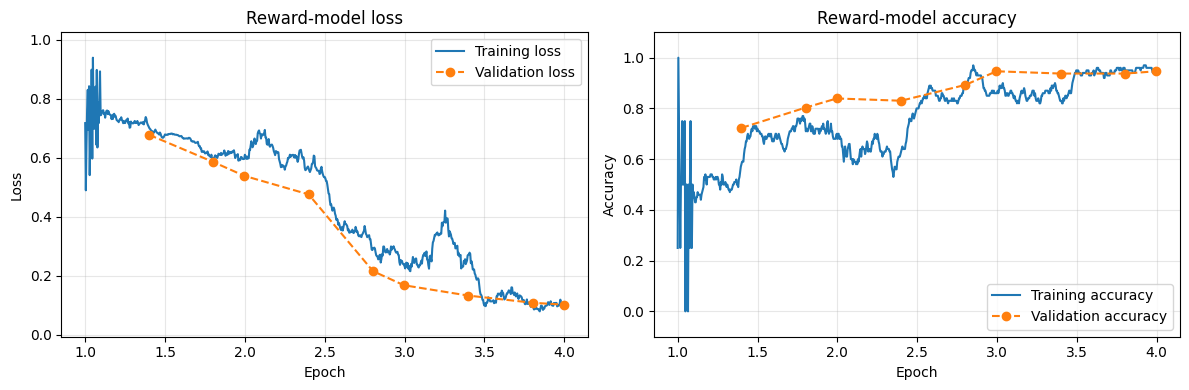

In [10]:

if rm_train_history:
    rm_steps_per_epoch = len(rm_train_loader)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_train_eval_curve(
        axes[0],
        rm_train_history,
        rm_eval_history,
        metric_key='loss',
        train_label='Training loss',
        eval_label='Validation loss',
        ylabel='Loss',
        title='Reward-model loss',
        steps_per_epoch=rm_steps_per_epoch,
        smoothing_window=PLOT_SMOOTHING_WINDOW,
        y_limit_min_epoch=PLOT_Y_LIMIT_WARMUP_EPOCHS,
    )
    plot_train_eval_curve(
        axes[1],
        rm_train_history,
        rm_eval_history,
        metric_key='accuracy',
        train_label='Training accuracy',
        eval_label='Validation accuracy',
        ylabel='Accuracy',
        title='Reward-model accuracy',
        steps_per_epoch=rm_steps_per_epoch,
        smoothing_window=PLOT_SMOOTHING_WINDOW,
        y_limit_min_epoch=PLOT_Y_LIMIT_WARMUP_EPOCHS,
    )
    plt.tight_layout()
    plt.show()
else:
    print('Run the reward-model training cell first to populate the diagnostics curves.')



## DPO section

Next, let's move to DPO. The reward model from Part 1 can tell us which response looks better, but it does not generate text by itself. DPO uses preference data to directly improve a language model.

Here the same SFT GPT-2 checkpoint appears in two roles:
- the **reference model**, which stays frozen and represents the original SFT behavior
- the **policy model**, which starts from the same weights but is updated during DPO

This distinction matters because DPO trains the policy relative to the reference. In other words, we are not only asking whether a response is good; we are asking whether the updated policy prefers the chosen answer more strongly than the frozen SFT baseline does.

This section maps directly to `q3_dpo.py`. Complete these student functions before running the training cell below:
- `compute_log_probs`
- `compute_dpo_loss`
- `DPOTrainer.compute_loss`

This is the DPO part of the RLHF pipeline, and the original DPO paper is [Direct Preference Optimization: Your Language Model is Secretly a Reward Model](https://arxiv.org/abs/2305.18290).

`compute_implicit_reward` is provided for analysis and notebook logging.

Key equations used here:

$$\log \pi_\theta(y \mid x) = \sum_t \log p_\theta(y_t \mid x, y_{<t})$$

$$\mathcal{L}_{DPO} = -\mathbb{E}\left[\log \sigma\left(\beta\left(\log \frac{\pi_\theta(y_w \mid x)}{\pi_{ref}(y_w \mid x)} - \log \frac{\pi_\theta(y_l \mid x)}{\pi_{ref}(y_l \mid x)}\right)\right)\right]$$

$$\hat r(x, y) = \beta (\log \pi_\theta(y \mid x) - \log \pi_{ref}(y \mid x))$$


In [11]:

print('DPO target functions: compute_log_probs, compute_dpo_loss, DPOTrainer.compute_loss')
print('Helper provided for analysis: compute_implicit_reward')

policy_chosen = torch.tensor([3.2, 1.4])
policy_rejected = torch.tensor([2.1, 1.1])
ref_chosen = torch.tensor([2.8, 1.3])
ref_rejected = torch.tensor([2.0, 1.0])
dpo_loss, reward_margin, dpo_accuracy = compute_dpo_loss(
    policy_chosen,
    policy_rejected,
    ref_chosen,
    ref_rejected,
    beta=0.1,
)
print('Synthetic DPO loss:', dpo_loss.item())
print('Synthetic reward margin:', reward_margin)
print('Synthetic DPO accuracy:', dpo_accuracy.item())
print('Synthetic implicit rewards:', compute_implicit_reward(policy_chosen, ref_chosen, beta=0.1))

policy_model = AutoModelForCausalLM.from_pretrained(ARTIFACT_PATHS['sft_model_dir'])
reference_model = AutoModelForCausalLM.from_pretrained(ARTIFACT_PATHS['sft_model_dir'])
dpo_optimizer = torch.optim.AdamW(policy_model.parameters(), lr=DPO_LR)
dpo_trainer = DPOTrainer(policy_model, reference_model, optimizer=dpo_optimizer, beta=0.1, device=DEVICE)

dpo_metrics_before = dpo_trainer.evaluate_loader(dpo_eval_loader)
print('DPO eval before training:', dpo_metrics_before)

dpo_train_result = train_dpo(
    dpo_trainer,
    dpo_train_loader,
    epochs=DPO_EPOCHS,
    grad_accum_steps=DPO_GRAD_ACCUM_STEPS,
    log_every=TRAINING_LOG_EVERY,
    eval_loader=dpo_eval_loader,
    eval_every=DPO_EVAL_EVERY,
    return_history=True,
)
dpo_train_summary = dpo_train_result['summary']
dpo_train_history = dpo_train_result['history']
dpo_eval_history = dpo_train_result['eval_history']
dpo_metrics_after = dpo_trainer.evaluate_loader(dpo_eval_loader)
policy_model_for_eval = dpo_trainer.policy_model
print('DPO training summary:', dpo_train_summary)
print('DPO eval after training:', dpo_metrics_after)


DPO target functions: compute_log_probs, compute_dpo_loss, DPOTrainer.compute_loss
Helper provided for analysis: compute_implicit_reward
Synthetic DPO loss: 0.6857033967971802
Synthetic reward margin: tensor([0.0300, 0.0000])
Synthetic DPO accuracy: 0.5
Synthetic implicit rewards: tensor([0.0400, 0.0100])
DPO eval before training: {'loss': 0.6931471824645996, 'reward_margin': 0.0, 'accuracy': 0.0}
DPO epoch 1/3 step 25/248 loss=1.1448 reward_margin=-0.6345 accuracy=0.5000
DPO epoch 1/3 step 50/248 loss=0.7718 reward_margin=-0.1054 accuracy=0.2500
DPO epoch 1/3 step 75/248 loss=0.8507 reward_margin=-0.2331 accuracy=0.2500
DPO epoch 1/3 step 100/248 loss=0.6535 reward_margin=0.0943 accuracy=0.5000
DPO validation @ step 100/248 loss=0.6155 reward_margin=0.1777 accuracy=0.8125
DPO epoch 1/3 step 125/248 loss=0.6611 reward_margin=0.0653 accuracy=1.0000
DPO epoch 1/3 step 150/248 loss=0.6534 reward_margin=0.0877 accuracy=0.7500
DPO epoch 1/3 step 175/248 loss=0.4036 reward_margin=0.7311 accu


## DPO diagnostics

Use these plots to study both optimization progress and possible instability. In your report, connect the loss and reward-margin trends to the final generations rather than treating the curves as sufficient evidence on their own.

A few interpretation hints:
- If the loss trends downward, the policy is fitting the preference objective more successfully.
- If the reward margins become more positive, the policy is separating chosen responses from rejected ones more strongly than the reference model does.
- If the curves become noisy or the generations later look worse, discuss possible instability or over-optimization instead of trusting the metrics blindly.

So these plots are useful, but they are still indirect evidence. Before concluding that DPO helped, we should inspect actual responses from the reference model and the updated policy model.


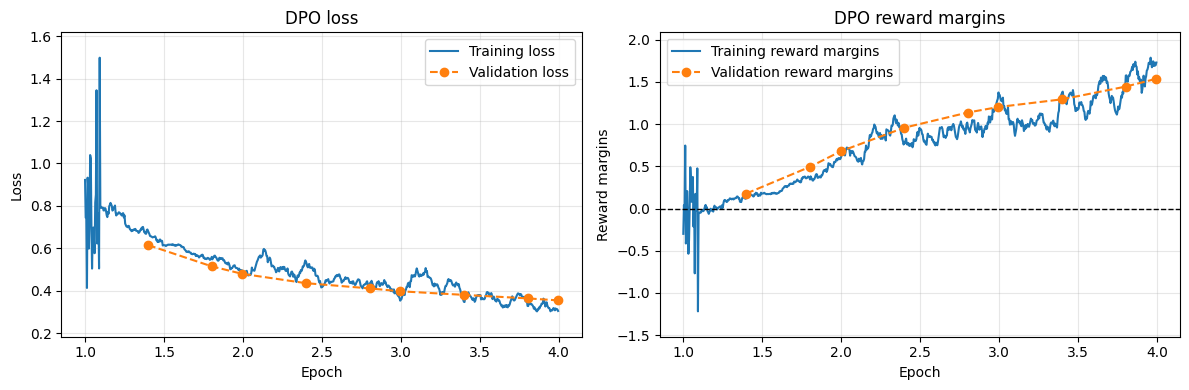

In [12]:

if dpo_train_history:
    dpo_steps_per_epoch = len(dpo_train_loader)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    plot_train_eval_curve(
        axes[0],
        dpo_train_history,
        dpo_eval_history,
        metric_key='loss',
        train_label='Training loss',
        eval_label='Validation loss',
        ylabel='Loss',
        title='DPO loss',
        steps_per_epoch=dpo_steps_per_epoch,
        smoothing_window=PLOT_SMOOTHING_WINDOW,
        y_limit_min_epoch=PLOT_Y_LIMIT_WARMUP_EPOCHS,
    )
    plot_train_eval_curve(
        axes[1],
        dpo_train_history,
        dpo_eval_history,
        metric_key='reward_margin',
        train_label='Training reward margins',
        eval_label='Validation reward margins',
        ylabel='Reward margins',
        title='DPO reward margins',
        steps_per_epoch=dpo_steps_per_epoch,
        smoothing_window=PLOT_SMOOTHING_WINDOW,
        y_limit_min_epoch=PLOT_Y_LIMIT_WARMUP_EPOCHS,
        include_zero=True,
    )
    axes[1].axhline(0.0, color='black', linestyle='--', linewidth=1)
    plt.tight_layout()
    plt.show()
else:
    print('Run the DPO training cell first to populate the diagnostics curves.')


### Reference model vs. policy model

Now we compare the frozen reference model with the DPO-updated policy model on held-out prompts. The reward model scores both outputs, but do not stop there: read the text carefully and look for changes in helpfulness, politeness, specificity, and refusal style. Small shifts still count. Also note any cases where the reward score and your own judgment disagree, since those mismatches are useful evidence about reward-model limitations.

In [13]:


import torch
from q3_utils import encode_prompt_response

COMPARE_PROMPT_COUNT = 10
COMPARE_MAX_NEW_TOKENS = 64

reference_model.eval()

if policy_model_for_eval is not None:
    policy_model_to_compare = policy_model_for_eval
elif 'dpo_trainer' in globals():
    policy_model_to_compare = dpo_trainer.policy_model
else:
    policy_model_to_compare = policy_model

policy_model_to_compare.eval()
from q3_utils import encode_prompt_response

def score_response(prompt, response):
    encoded = encode_prompt_response(prompt, response, tokenizer, max_length=DEFAULT_MAX_LENGTH)
    batch = {
        "input_ids": torch.tensor([encoded["input_ids"]], device=DEVICE),
        "attention_mask": torch.tensor([encoded["attention_mask"]], device=DEVICE),
    }
    with torch.no_grad():
        score = reward_model(batch["input_ids"], batch["attention_mask"]).item()
    return score

def generate_response(model, prompt, max_new_tokens=64):
    inputs = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    full_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = full_text[len(prompt):] if full_text.startswith(prompt) else full_text
    return response.strip()

comparison_prompts = [record["prompt"] for record in test_records[:COMPARE_PROMPT_COUNT]]


for i, prompt in enumerate(comparison_prompts, start=1):
    ref_text = generate_response(reference_model, prompt, max_new_tokens=COMPARE_MAX_NEW_TOKENS)
    policy_text = generate_response(policy_model_to_compare, prompt, max_new_tokens=COMPARE_MAX_NEW_TOKENS)

    ref_score = score_response(prompt, ref_text)
    policy_score = score_response(prompt, policy_text)

    print("=" * 100)
    print(f"Prompt {i}")
    print("=" * 100)
    print(prompt)
    print()
    print(f"[Reference model response | reward={ref_score:.4f}]")
    print(ref_text)
    print()
    print(f"[Policy model response | reward={policy_score:.4f}]")
    print(policy_text)
    print()


Prompt 1
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Find the next 3 terms in the following sequence: 4, 8, 12, 16.

### Response:


[Reference model response | reward=1.4299]
The next three terms in the sequence are: 3, 8, 12, 16.

[Policy model response | reward=1.4299]
The next three terms in the sequence are: 3, 8, 12, 16.

Prompt 2
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Translate 'Where can I buy tickets?' into Italian.

### Response:


[Reference model response | reward=0.4012]
The Italian translation of 'Where can I buy tickets?' is 'Ti amo'.

[Policy model response | reward=0.1549]
The Italian translation of 'Where can I buy tickets?' is 'Ti amo è l'altro?'.

Prompt 3
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Change the sentences from 


## Best-of-N section

Finally, we move to an inference-time alignment method. Unlike DPO, Best-of-N does not update model weights. Instead, it samples several candidate responses from the policy model and lets the reward model choose the highest-scoring one.

This makes the connection across the notebook explicit: Part 1 produced the reward model used for ranking, Part 2 produced the policy model used for generation, and Part 3 combines them at inference time.

This section maps directly to `q3_bon.py`. Complete this student function before running the demo and report cells:
- `best_of_n_sample`

`select_best_of_n` is a provided helper for response ranking.

The implementation is just the ranking rule applied after sampling multiple candidates:

$$y^* = \arg\max_{i \in [N]} r_\phi(x, y_i)$$


In [14]:

print('Best-of-N target function: best_of_n_sample')
print('Helper provided for ranking: select_best_of_n')

demo_prompt = report_prompts[4]
best_text, best_reward, all_rewards = best_of_n_sample(
    policy_model_for_eval,
    reward_model,
    tokenizer,
    prompt=demo_prompt,
    n=4,
    max_new_tokens=REPORT_MAX_NEW_TOKENS,
    temperature=REPORT_TEMPERATURE,
)
print('Held-out evaluation prompt:')
print(demo_prompt)
print('All rewards:', all_rewards.tolist())
print('Selected reward:', best_reward)
print('Selected response:')
print(best_text)


Best-of-N target function: best_of_n_sample
Helper provided for ranking: select_best_of_n
Held-out evaluation prompt:
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Explain what a sonnet is.

### Response:

All rewards: [1.8252395391464233, 1.8453000783920288, 2.8322315216064453, 4.084647178649902]
Selected reward: 4.084647178649902
Selected response:
A sonnet is a written rhyming or lyrical composition in which the speaker invokes the theme of love, devotion, and joy in a song.



## Report guidance

Use the figures and outputs in this notebook to support the report questions in the assignment handout.

Your report for Part D should mainly address the two required questions below.

- DPO vs PPO (theory): use the DPO objective to explain how DPO learns directly from preference pairs without running PPO-style policy optimization against an explicit reward model. Clearly describe the role of the frozen reference model $\pi_{\text{ref}}$ and discuss what would happen if this regularization effect were weakened or removed, for example when $\beta$ -> 0. Give one advantage and one disadvantage of DPO relative to PPO-based RLHF.
- Best-of-N analysis: use at least 5 prompts and report results for `N in {1, 4, 8, 16, 32}`. Plot the mean reward as a function of `N` and describe the trend.
- Qualitative comparison: for one prompt, show the Best-of-1 and Best-of-16 responses side by side. Comment on qualitative differences and discuss whether a higher reward always matches your own judgment.
- Reward-model limitations: when reward scores and human judgment disagree, explain what this suggests about the limitations of the learned reward signal.



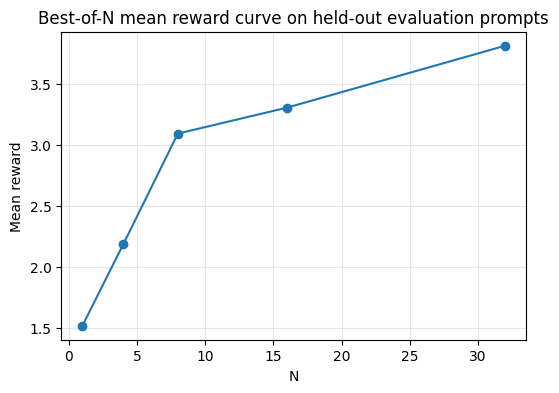

Display prompt (index 4):
Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
Explain what a sonnet is.

### Response:


Best-of-1 response | reward=3.7809
A sonnet is a type of poetic composition in which the primary subject is a child or child-like figure. It typically begins with the words 'I am' or 'I sing.'

Best-of-16 response | reward=6.3720
A sonnet is a piece of music composed for the sole purpose of expressing an idea. It typically begins with a strong, melodic voice, which typically changes to a more verse or a more lyrical voice, typically in the second or


In [15]:
RUN_REPORT_DEMO = True
DISPLAY_PROMPT_INDEX = 4  # feel free to try different example to see

if RUN_REPORT_DEMO:
    reward_table, exemplar_texts = evaluate_best_of_n_curve(
        policy_model_for_eval,
        reward_model,
        tokenizer,
        prompts=report_prompts,
        n_values=REPORT_N_VALUES,
        max_new_tokens=REPORT_MAX_NEW_TOKENS,
        temperature=REPORT_TEMPERATURE,
    )

    mean_rewards = mean_reward_by_n(reward_table)
    plt.figure(figsize=(6, 4))
    plt.plot(list(mean_rewards.keys()), list(mean_rewards.values()), marker='o')
    plt.xlabel('N')
    plt.ylabel('Mean reward')
    plt.title('Best-of-N mean reward curve on held-out evaluation prompts')
    plt.grid(True, alpha=0.3)
    plt.show()

    display_prompt = report_prompts[DISPLAY_PROMPT_INDEX]

    best1_text, best1_reward, _ = best_of_n_sample(
        policy_model_for_eval,
        reward_model,
        tokenizer,
        prompt=display_prompt,
        n=1,
        max_new_tokens=REPORT_MAX_NEW_TOKENS,
        temperature=REPORT_TEMPERATURE,
    )

    best16_text, best16_reward, _ = best_of_n_sample(
        policy_model_for_eval,
        reward_model,
        tokenizer,
        prompt=display_prompt,
        n=16,
        max_new_tokens=REPORT_MAX_NEW_TOKENS,
        temperature=REPORT_TEMPERATURE,
    )

    print(f'Display prompt (index {DISPLAY_PROMPT_INDEX}):')
    print(display_prompt)
    print()

    print(f'Best-of-1 response | reward={best1_reward:.4f}')
    print(best1_text)
    print()

    print(f'Best-of-16 response | reward={best16_reward:.4f}')
    print(best16_text)
else:
    print('Set RUN_REPORT_DEMO = True after you have run the earlier training sections.')



## Submission checklist

Before you submit, make sure you have:
- completed `q3_reward_model.py`, `q3_dpo.py`, and `q3_bon.py`
- rerun the notebook after editing those files
- saved the figures and observations you need for your report
- confirmed that the prepared artifacts are in the expected `artifacts/q3_rlhf/` location
